In [1]:
# Next Notebook

# ⚠️ Step 4: Handle Outliers (Important)

# Focus on:

# annual_inc
# loan_amnt
# dti

# 👉 Use capping (IQR method)

# def cap_outliers(col):
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
    
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
    
#     df[col] = df[col].clip(lower, upper)

# for col in ['annual_inc','loan_amnt','dti']:
#     cap_outliers(col)
# 🧠 Step 5: Encode Basic Categories (Light Encoding Only)

# 👉 Don’t go heavy yet (Day 4 is for that)

# For now:

# df = pd.get_dummies(df, drop_first=True)

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/processed_stage2.csv")  # put correct path

df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,target1
0,9600.0,36,12.99,323.42,C,C1,Teacher,10,RENT,21900.0,...,0.0,11600.0,4509.0,2400.0,0.0,N,Cash,N,0,0
1,4000.0,36,6.68,122.93,A,A3,System Analyst,4,MORTGAGE,83000.0,...,0.0,222616.0,64253.0,5600.0,76154.0,N,Cash,N,0,0
2,6025.0,36,10.91,197.00,B,B4,Admin assistant,10,RENT,52000.0,...,0.0,32227.0,5559.0,11000.0,11127.0,N,Cash,N,0,0
3,20000.0,36,9.49,640.57,B,B2,Manager,10,MORTGAGE,100000.0,...,0.0,322295.0,33695.0,23900.0,29995.0,N,Cash,N,0,0
4,1000.0,36,8.18,31.42,B,B1,Teacher,10,RENT,23000.0,...,0.0,9979.0,7252.0,1700.0,5779.0,N,Cash,N,0,0


In [4]:
df.shape

(59494, 79)

Outliers in finance are often real signals of risk, not errors.

🧠 How to Think About Outliers (VERY IMPORTANT)

In your case (loan default prediction):

A person with very high loan → could be risky
Very high DTI → definitely risky
Very low income → risky

👉 These are NOT errors
👉 These are valuable signals

🚀 Correct Strategy (Industry Approach)
❌ DO NOT:
1. Remove all outliers blindly
2. Use IQR and drop rows directly


✅ DO:
Analyze first → then decide
🔍 Step 1 — Detect Outliers

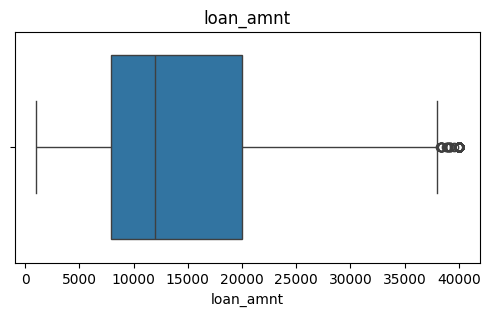

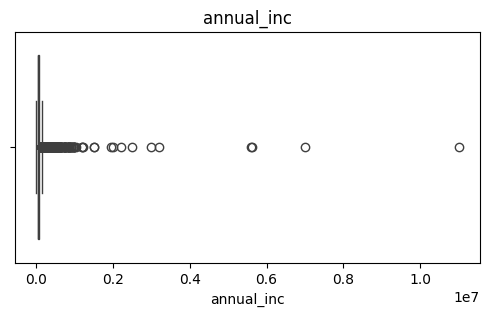

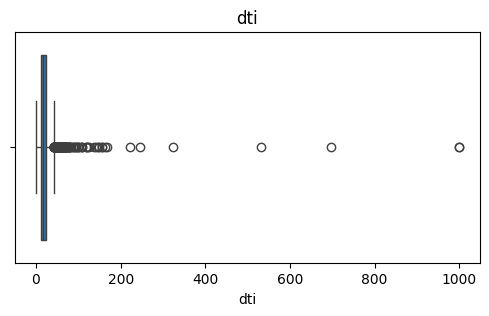

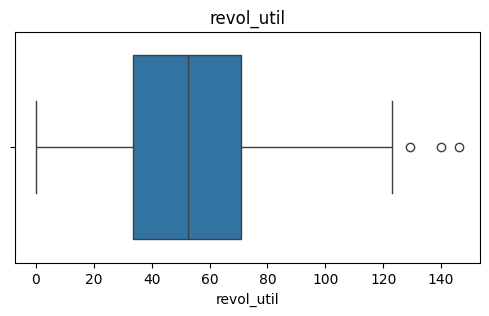

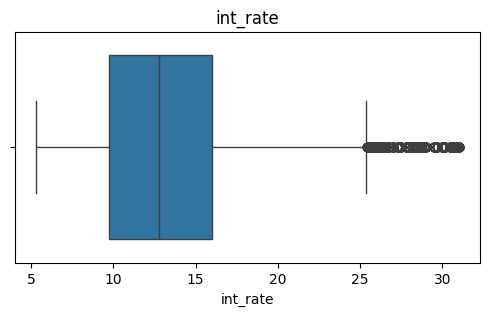

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_util', 'int_rate']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

🧠 Step 2 — Decide Column-wise Strategy

Here’s the correct decision table 👇

| Column       | What to Do            | Why                        |
| ------------ | --------------------- | -------------------------- |
| `loan_amnt`  | Keep / Cap            | High loans = real risk     |
| `annual_inc` | Cap                   | Extreme values unrealistic |
| `dti`        | Keep (very important) | Strong risk signal         |
| `int_rate`   | Keep                  | Market-driven              |
| `revol_util` | Cap                   | Sometimes noisy            |





🔧 Step 3 — Apply Capping (BEST METHOD)

Instead of removing rows, use Winsorization (capping)

✅ Example: Cap at 1st & 99th percentile

In [10]:
for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    
    df[col] = df[col].clip(lower, upper)

🔥 Why Capping is Better

Keeps all data ✅

Reduces extreme noise ✅

Works well for ML models ✅

⚠️ Special Case — DTI

👉 DO NOT aggressively cap dti

Why?

It’s one of the strongest predictors of default


🧪 Step 4 — Recheck After Capping

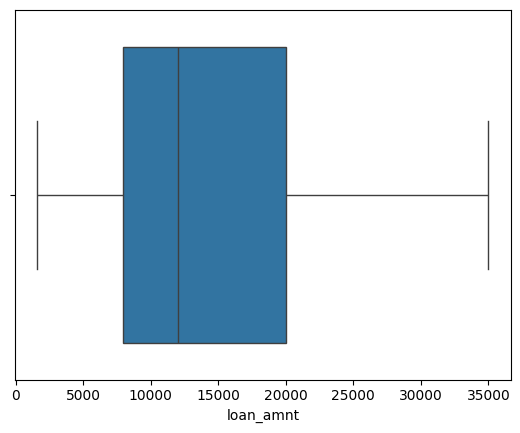

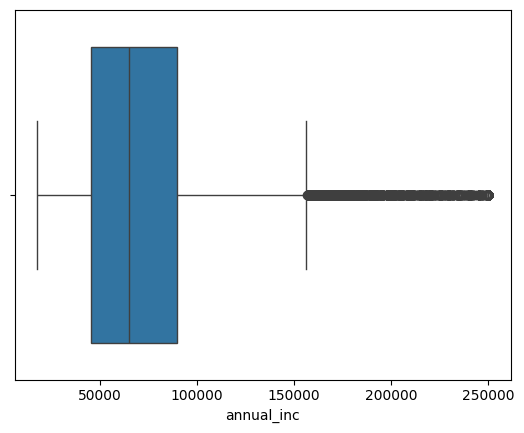

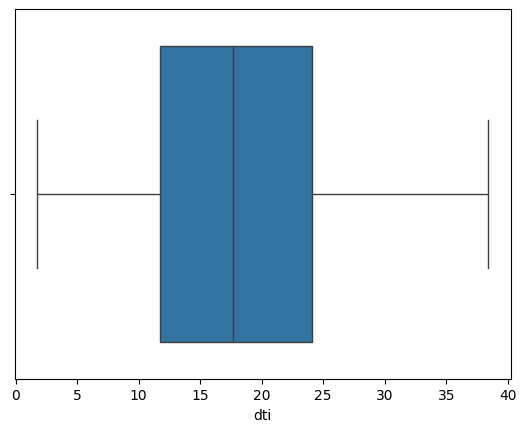

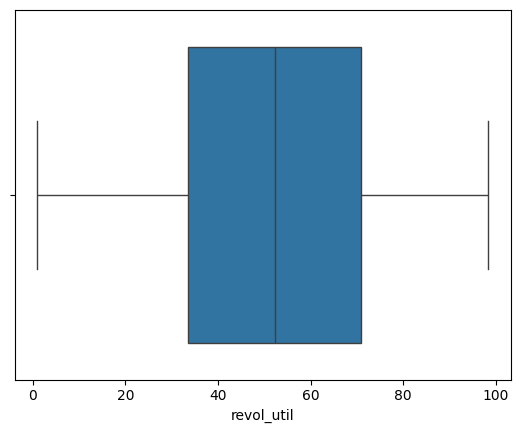

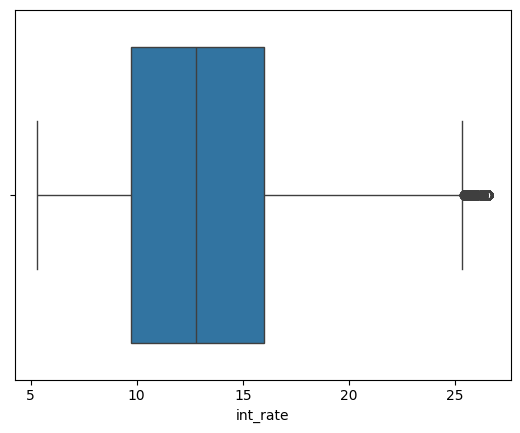

In [11]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

🧾 Step 5 — Document This (VERY IMPORTANT)

Write in your notebook:

“Outliers were handled using percentile-based capping to retain extreme but meaningful financial behavior while reducing noise.”

💥 This sounds very professional

🏁 Final Answer to Your Question

👉 YES, handle outliers
👉 BUT:

Don’t delete blindly
Use capping (preferred)
Keep important signals

In [ ]:
# Let us analyse the outliers and decide what to do

: 

In [6]:
df['annual_inc'].describe()

count    5.949400e+04
mean     7.634979e+04
std      8.417571e+04
min      0.000000e+00
25%      4.546625e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

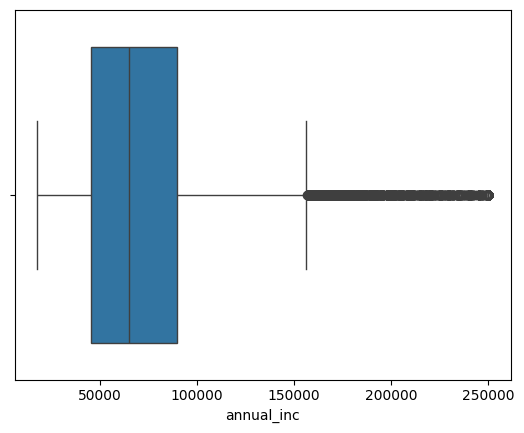

: 

In [ ]:
sns.boxplot(x=df['annual_inc'])
plt.show()

In [ ]:
df[df['annual_inc']==250000]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,target1
180,20000.0,36,6.99,617.46,A,A2,Physician,2,MORTGAGE,250000.0,...,0.0,890633.0,195676.0,42900.0,141758.0,N,Cash,N,0,0
320,20000.0,36,8.59,632.19,A,A5,RN,5,MORTGAGE,250000.0,...,2.0,518900.0,13649.0,22000.0,0.0,N,Cash,N,0,0
408,20000.0,60,8.19,407.35,A,A5,National Account Manager,6,MORTGAGE,250000.0,...,0.0,954019.0,242160.0,144800.0,103019.0,N,Cash,Y,1,1
475,30000.0,60,10.75,648.54,B,B4,Vice President,6,MORTGAGE,250000.0,...,0.0,611998.0,189818.0,19225.0,117578.0,N,Cash,N,1,1
730,6000.0,36,6.99,185.24,A,A2,Director Medical Surgical Specialties,1,MORTGAGE,250000.0,...,0.0,226550.0,122193.0,86400.0,105618.0,N,Cash,N,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59195,7000.0,36,16.02,246.17,C,C5,Director,1,MORTGAGE,250000.0,...,0.0,764410.0,84211.0,37100.0,78010.0,N,Cash,N,0,0
59203,12000.0,36,20.31,447.87,D,D5,memorial HCA,8,OWN,250000.0,...,0.0,115913.0,58072.0,11700.0,97013.0,N,Cash,N,0,0
59219,35000.0,36,8.90,1111.37,A,A5,Executive Director,10,MORTGAGE,250000.0,...,0.0,845803.0,94497.0,67900.0,47803.0,N,Cash,N,0,0
59318,35000.0,60,18.24,893.35,D,D5,Regional Business Development Manager,1,RENT,250000.0,...,0.0,124662.0,104907.0,16000.0,74662.0,N,Cash,N,1,1


: 

In [8]:
df[df['annual_inc']>500000][['dti','int_rate','annual_inc','loan_amnt','revol_util','target']]


,dti,int_rate,annual_inc,loan_amnt,revol_util,target
1770,10.89,14.65,602646.0,25250.0,40.1,0
3104,0.65,18.55,3200000.0,18000.0,6.2,1
3197,5.14,10.42,721000.0,28000.0,12.6,0
3523,9.36,11.39,720000.0,35000.0,39.5,0
3966,6.32,16.01,621000.0,35000.0,32.1,0
...,...,...,...,...,...,...
55978,19.11,18.99,591000.0,30000.0,13.6,1
57122,2.86,6.49,1200000.0,28000.0,48.6,0
57397,5.37,13.49,600000.0,40000.0,15.0,0
57713,1.62,9.43,850000.0,12000.0,42.2,1


In [ ]:
df.groupby('target')[['dti','int_rate','revol_util','annual_inc']].mean()  #check before and afte capping

,dti,int_rate,revol_util,annual_inc
target,,,,
0,17.668850,12.658840,51.126245,75707.829967
1,20.028715,15.710587,55.140302,69514.550864


In [ ]:
df[df['annual_inc']>150000]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,target1
36,7000.0,36,9.91,225.58,B,B1,New Wave Entertainment,5,MORTGAGE,156000.0,...,0.0,112059.0,37212.0,15000.0,31606.0,N,Cash,N,0,0
61,18000.0,60,20.00,476.89,D,D4,CFO,5,MORTGAGE,170000.0,...,0.0,562326.0,298729.0,29200.0,273286.0,N,Cash,N,0,0
117,24000.0,36,11.99,797.03,C,C1,Director,4,MORTGAGE,167000.0,...,2.0,583949.0,55246.0,21300.0,60649.0,N,Cash,N,0,0
180,20000.0,36,6.99,617.46,A,A2,Physician,2,MORTGAGE,250000.0,...,0.0,890633.0,195676.0,42900.0,141758.0,N,Cash,N,0,0
194,32000.0,60,10.42,686.54,B,B3,Real estate agent,3,MORTGAGE,176000.0,...,0.0,83932.0,62685.0,21300.0,50132.0,N,Cash,N,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59383,9600.0,36,7.89,300.35,A,A5,"IT Leader, Innovation",10,MORTGAGE,170000.0,...,0.0,109200.0,81405.0,82200.0,0.0,N,Cash,N,0,0
59413,35000.0,36,9.17,1115.77,B,B2,Project Manager,10,MORTGAGE,168000.0,...,0.0,289700.0,60016.0,71800.0,0.0,N,Cash,N,0,0
59465,28000.0,36,6.24,854.87,A,A2,Engineer V,5,MORTGAGE,200000.0,...,0.0,626500.0,384.0,21500.0,0.0,N,Cash,N,0,0
59480,20000.0,36,7.89,625.72,A,A5,Product Director,10,OWN,193064.0,...,0.0,944650.0,70391.0,7000.0,25003.0,N,Cash,N,0,0


: 

: 

# Univariate and Bivariate Analysis

Step 1 — Numerical Columns

Focus ONLY on important ones:

In [13]:
cols = ['dti', 'int_rate', 'annual_inc', 'loan_amnt', 'revol_util']

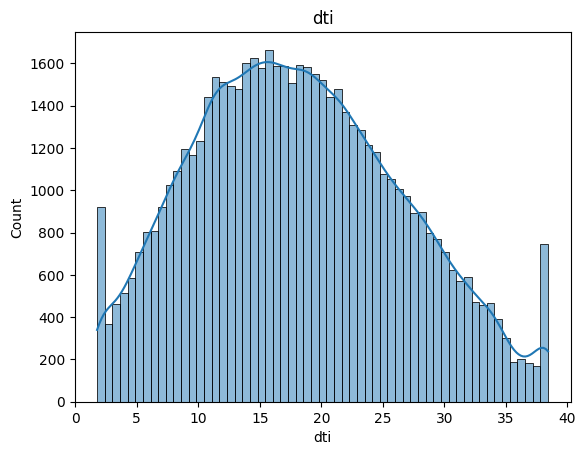

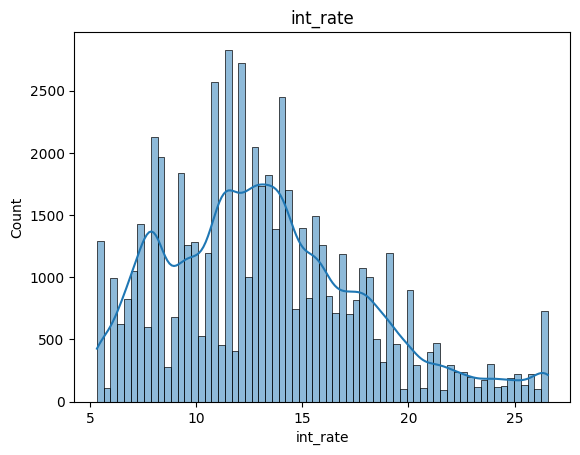

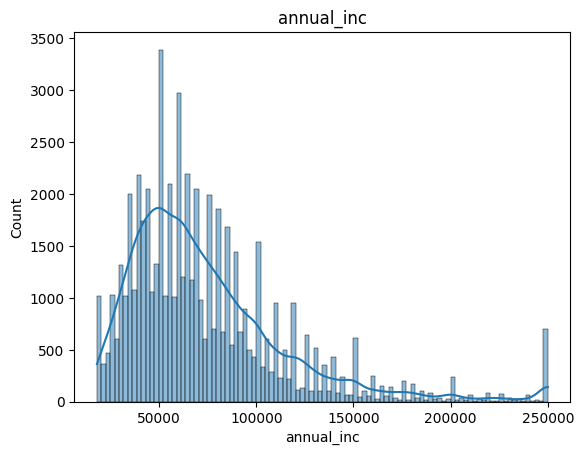

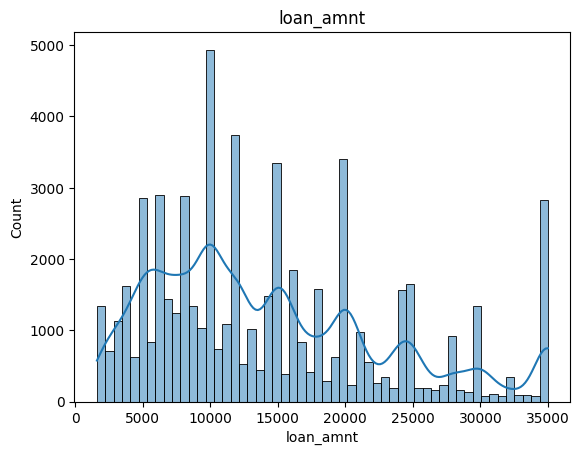

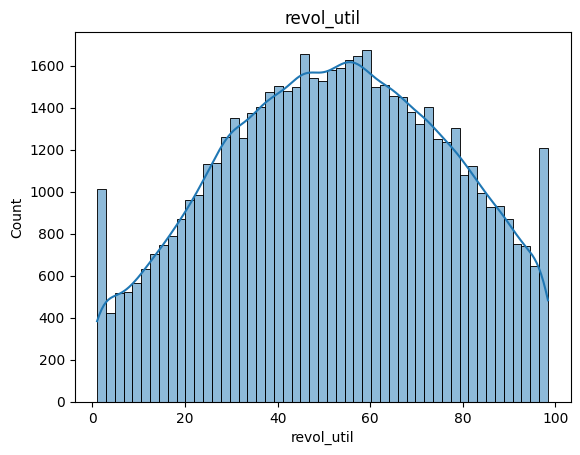

In [14]:
for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

What to Observe

For EACH column, answer:

1️⃣ Is it skewed?
Right skew → common in finance
2️⃣ Where is most data?
Example: DTI mostly between 10–25
3️⃣ Any strange shape?
Multiple peaks?
✍️ Example Insight

“DTI distribution is right-skewed with most values concentrated between 10–25.”

🔤 Step 2 — Categorical Columns

Focus on:

In [15]:
cat_cols = ['home_ownership', 'emp_length', 'verification_status']

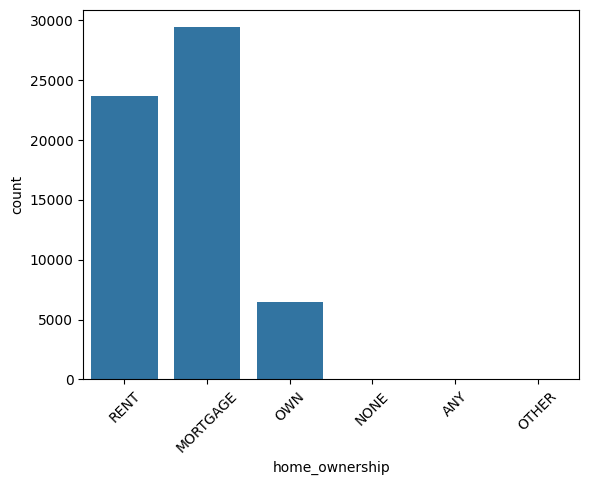

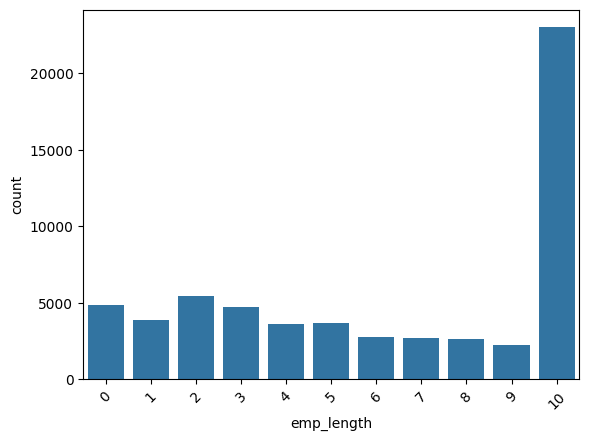

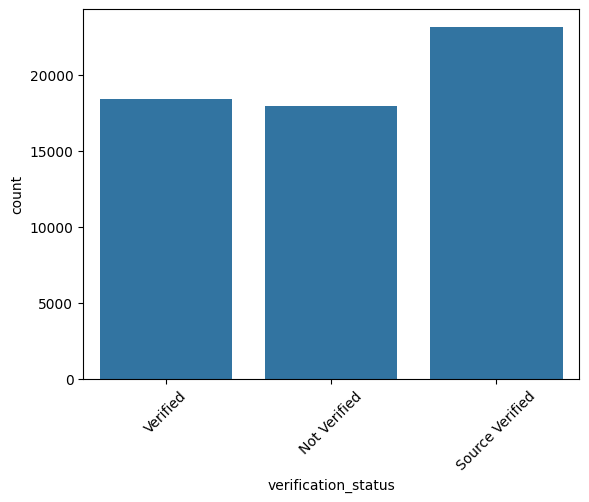

In [16]:
for col in cat_cols:
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

# PART 2 — BIVARIATE ANALYSIS (MOST IMPORTANT)
🎯 Goal:

“How does each feature affect default?”

🔥 A. Numerical vs Target
1️⃣ DTI vs Default

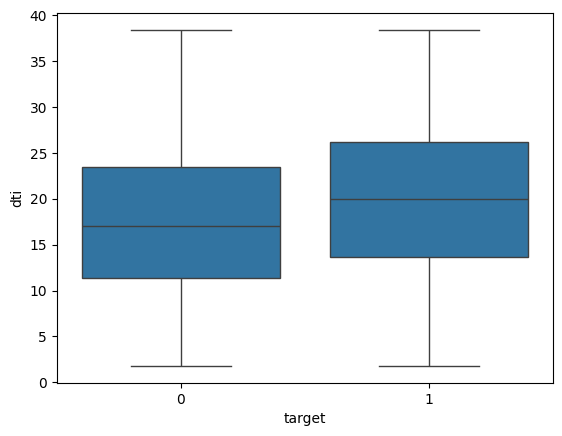

In [17]:
sns.boxplot(x='target', y='dti', data=df)
plt.show()

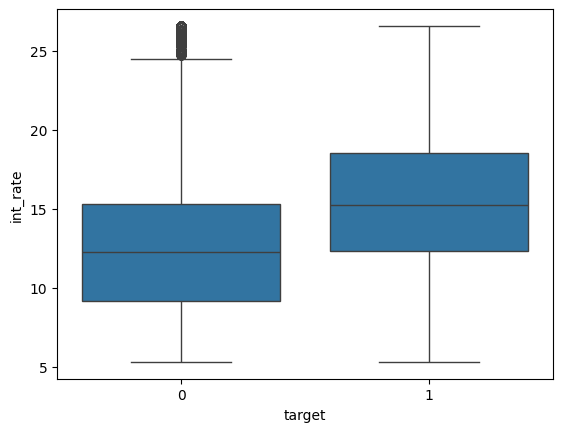

In [20]:
sns.boxplot(x='target', y='int_rate', data=df)
plt.show()

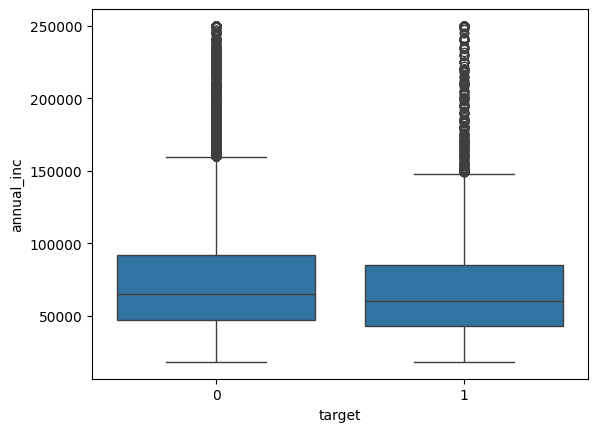

In [19]:
sns.boxplot(x='target', y='annual_inc', data=df)
plt.show()

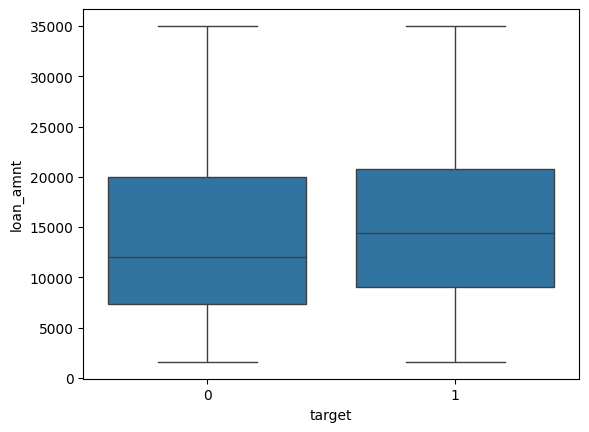

In [21]:
sns.boxplot(x='target', y='loan_amnt', data=df)
plt.show()

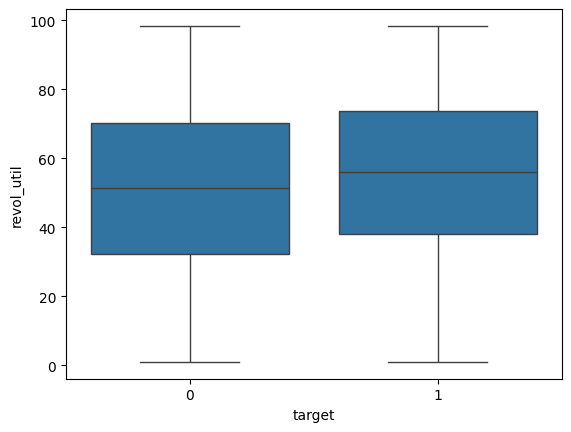

In [22]:
sns.boxplot(x='target', y='revol_util', data=df)
plt.show()

# What to Observe

For EACH plot:

👉 Compare:

Median of target 0 vs 1
Spread
✍️ Example Insight

“Defaulters tend to have higher median DTI compared to non-defaulters.”

🔥 B. Categorical vs Target
Home Ownership

In [24]:
pd.crosstab(df['home_ownership'], df['target'], normalize='index')


target,0,1
home_ownership,,
ANY,0.923077,0.076923
MORTGAGE,0.821560,0.178440
NONE,0.400000,0.600000
OTHER,0.857143,0.142857
OWN,0.796994,0.203006
RENT,0.768283,0.231717


In [25]:
pd.crosstab(df['emp_length'], df['target'], normalize='index')

target,0,1
emp_length,,
0,0.794063,0.205937
1,0.784528,0.215472
2,0.796109,0.203891
3,0.805101,0.194899
4,0.797335,0.202665
5,0.818577,0.181423
6,0.805976,0.194024
7,0.799478,0.200522
8,0.801662,0.198338


In [26]:
pd.crosstab(df['verification_status'], df['target'], normalize='index')

target,0,1
verification_status,,
Not Verified,0.849601,0.150399
Source Verified,0.790055,0.209945
Verified,0.756785,0.243215


# 🧠 What to Observe

👉 Which category has:

Higher % of default?
✍️ Example Insight

“Renters show slightly higher default rates compared to homeowners.”

🚨 VERY IMPORTANT RULE

👉 Don’t just plot — INTERPRET

For EVERY graph, ask:

“Why is this happening?”

🏁 Final Output of This Step

By end, you should have:

5–8 clear insights
Understanding of:
Risk patterns
Borrower behavior
🚀 Your Task NOW

Do this:

1️⃣ Run:
Histplots (univariate)
Boxplots (bivariate)
2️⃣ Write:

At least 5 observations

In [ ]:
# Defaulters tend to have higher median of dti, interest rate, loan amount and revolving credit utilisation and lower median of annual income.
# Renters show highr percentage of default than houseowners. The eomployer length does not matter much as trend show around 20% default cases in each category. Verification status show not verified did 15% default and verified one did 24% default. 



 “Defaulters exhibit higher median debt-to-income ratios, interest rates, loan amounts, and credit utilization, while having lower median income compared to non-defaulters.”

“Borrowers with rented housing show a higher default rate compared to homeowners, indicating lower financial stability.”


“Employment length does not show a strong relationship with default, as default rates remain relatively consistent across different employment durations.”

4. Verification Status (IMPORTANT CORRECTION)

You said:

Not verified did 15% default and verified did 24% default

This looks counterintuitive, so we must interpret carefully.

🧠 Correct Interpretation:

“Verified borrowers show a higher default rate, which may indicate that higher-risk applicants are more likely to undergo income verification, reflecting underlying risk rather than causation.”

❗ Why This Happens:

Banks:

Verify income more for risky borrowers
👉 So:
Verified ≠ safer
Verified = already suspected risk

💥 This is a VERY IMPORTANT business insight

# FINAL TOP 6 INSIGHTS (RESUME READY)

You should present them like this:

✅ 1.

Borrowers with higher debt-to-income ratios are significantly more likely to default

✅ 2.

Higher interest rates strongly correlate with increased default risk

✅ 3.

Higher credit utilization indicates financial stress and increases default probability

✅ 4.

Lower income borrowers show a higher tendency to default

✅ 5.

Renters exhibit higher default rates compared to homeowners, suggesting lower financial stability

✅ 6 (ADVANCED)

Income verification is associated with higher default rates, likely because higher-risk borrowers are more frequently subjected to verification processes

In [27]:
df.to_csv("../data/processed/processed_stage3.csv", index=False)